In [1]:
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully.")
print("Dataset shape:", X.shape)
print("Classes:", iris.target_names)

Dataset loaded successfully.
Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preprocessing completed successfully.")

Data preprocessing completed successfully.


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.20,
    verbose=0
)

print("Model training completed successfully.")

Model training completed successfully.


In [8]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Loss: 0.2909
Test Accuracy: 83.33 %


In [9]:
prediction_probabilities = model.predict(
    X_test,
    verbose=0
)

predictions = np.argmax(
    prediction_probabilities,
    axis=1
)

print("Predictions generated successfully.")
print("Total predictions:", len(predictions))

Predictions generated successfully.
Total predictions: 30


In [10]:
print("ACTUAL VS PREDICTED RESULTS")
print("-" * 45)

for i in range(5):
    actual_class = iris.target_names[y_test[i]]
    predicted_class = iris.target_names[predictions[i]]

    print(
        f"Sample {i+1}: "
        f"Actual = {actual_class} | "
        f"Predicted = {predicted_class}"
    )

ACTUAL VS PREDICTED RESULTS
---------------------------------------------
Sample 1: Actual = setosa | Predicted = setosa
Sample 2: Actual = virginica | Predicted = virginica
Sample 3: Actual = versicolor | Predicted = versicolor
Sample 4: Actual = versicolor | Predicted = versicolor
Sample 5: Actual = setosa | Predicted = setosa


In [11]:
print(f"{'Sample':<10}{'Actual':<15}{'Predicted':<15}")
print("-" * 40)

for i in range(10):
    actual = iris.target_names[y_test[i]]
    predicted = iris.target_names[predictions[i]]

    print(
        f"{i+1:<10}"
        f"{actual:<15}"
        f"{predicted:<15}"
    )

Sample    Actual         Predicted      
----------------------------------------
1         setosa         setosa         
2         virginica      virginica      
3         versicolor     versicolor     
4         versicolor     versicolor     
5         setosa         setosa         
6         versicolor     virginica      
7         setosa         setosa         
8         setosa         setosa         
9         virginica      virginica      
10        versicolor     versicolor     


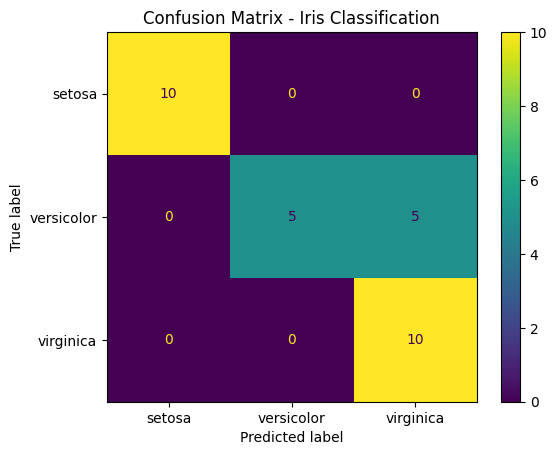

In [12]:
cm = confusion_matrix(
    y_test,
    predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()

plt.title("Confusion Matrix - Iris Classification")
plt.show()

In [13]:
correct_predictions = np.sum(y_test == predictions)
incorrect_predictions = np.sum(y_test != predictions)

print("Total test samples       :", len(y_test))
print("Correct predictions      :", correct_predictions)
print("Incorrect predictions    :", incorrect_predictions)
print(
    "Prediction accuracy      :",
    round(correct_predictions / len(y_test) * 100, 2),
    "%"
)

Total test samples       : 30
Correct predictions      : 25
Incorrect predictions    : 5
Prediction accuracy      : 83.33 %


In [14]:
incorrect_indices = np.where(
    y_test != predictions
)[0]

if len(incorrect_indices) == 0:
    print("There were no incorrect predictions.")
else:
    print("INCORRECT PREDICTIONS")
    print("-" * 50)

    for index in incorrect_indices:
        actual = iris.target_names[y_test[index]]
        predicted = iris.target_names[predictions[index]]

        print(
            f"Sample {index + 1}: "
            f"Actual = {actual} | "
            f"Predicted = {predicted}"
        )

INCORRECT PREDICTIONS
--------------------------------------------------
Sample 6: Actual = versicolor | Predicted = virginica
Sample 14: Actual = versicolor | Predicted = virginica
Sample 19: Actual = versicolor | Predicted = virginica
Sample 26: Actual = versicolor | Predicted = virginica
Sample 27: Actual = versicolor | Predicted = virginica


In [15]:
print("=" * 45)
print("TASK 4 - MODEL EVALUATION SUMMARY")
print("=" * 45)

print("Dataset              : Iris Flower Dataset")
print("Test samples         :", len(y_test))
print("Test accuracy        :", round(test_accuracy * 100, 2), "%")
print("Test loss            :", round(test_loss, 4))
print("Correct predictions  :", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)

TASK 4 - MODEL EVALUATION SUMMARY
Dataset              : Iris Flower Dataset
Test samples         : 30
Test accuracy        : 83.33 %
Test loss            : 0.2909
Correct predictions  : 25
Incorrect predictions: 5


Model Evaluation and Prediction
The trained neural network was evaluated using the test dataset, which contained 30 samples that were not used to train the model. Test accuracy was calculated to measure how successfully the model classified unseen Iris flowers.
The neural network generated a probability for each of the three classes: Setosa, Versicolor and Virginica. The class with the highest probability was selected as the final prediction. Actual and predicted classes were then compared to analyse the model's performance.
A confusion matrix was also created. The diagonal values in the matrix represent correctly classified samples, while values outside the diagonal represent incorrect classifications. Most samples were correctly classified, showing that the neural network learned meaningful relationships between the Iris flower measurements and their corresponding species.
Any incorrect predictions may occur because Versicolor and Virginica flowers can have similar feature measurements, making them more difficult for the model to distinguish. Overall, the evaluation demonstrates that the neural network is capable of making accurate predictions on previously unseen data.

Incorrect Prediction Explanation:

The model made 5 incorrect predictions out of 30 test samples. All five errors occurred when Versicolor flowers were predicted as Virginica. This may happen because Versicolor and Virginica have overlapping sepal and petal measurements, making them more difficult for the neural network to distinguish. The confusion matrix confirms that Setosa and Virginica were classified more accurately, while the main classification difficulty occurred between Versicolor and Virginica.